# Zomato Chennai Data Analysis

In [1]:
# importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'svg'

In [2]:
# load the dataset

raw_df = pd.read_csv("Zomato Chennai Listing 2020.csv")

In [3]:
raw_df.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


# Getting Basic Information about the Dataset

In [4]:
# To get the number of rowns and columns

raw_df.shape

(12032, 12)

In [5]:
# Overview to see the column name, data type, missing values.

raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [6]:
raw_df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


# Cleaning the Dataset

## a. Removing the redundunt rows of data

In [7]:
# Dropping columns which are not required for further analysis

raw_df.drop(['Zomato URL', 'Address'], axis=1, inplace=True)

In [8]:
raw_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


## b. Removing Null records

In [9]:
# To get Null values count

raw_df.isnull().sum()

Name of Restaurant          0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [10]:
# Replacing the null records with NA

raw_df = raw_df.fillna(0)

In [11]:
# Confirming all the null records are replaced

raw_df.isnull().sum()

Name of Restaurant       0
Location                 0
Cuisine                  0
Top Dishes               0
Price for 2              0
Dining Rating            0
Dining Rating Count      0
Delivery Rating          0
Delivery Rating Count    0
Features                 0
dtype: int64

## c. Converting the DataTypes of numerical columns to numeric dataype

In [12]:
# Checking for text values in 'Dining Rating Count' column before converting it to numeric datatype

raw_df['Dining Rating Count'].value_counts()

Dining Rating Count
Does not offer Dining        2603
Not enough Dining Reviews    2528
4                             339
5                             271
6                             248
                             ... 
877                             1
897                             1
872                             1
1197                            1
224                             1
Name: count, Length: 794, dtype: int64

In [13]:
# Replacing the text values with '0'

raw_df['Dining Rating Count'] = raw_df['Dining Rating Count'].replace(to_replace = ['Does not offer Dining','Not enough Dining Reviews'],value = 0)

In [14]:
# Checking for text values in 'Delivery Rating Count' column before converting it to numeric datatype

raw_df['Delivery Rating Count'].value_counts()

Delivery Rating Count
Not enough Delivery Reviews    3379
Does not offer Delivery        2252
0                               220
27                               34
37                               30
                               ... 
3530                              1
7705                              1
6374                              1
1773                              1
1617                              1
Name: count, Length: 2282, dtype: int64

In [15]:
# Replacing the text values with '0'

raw_df['Delivery Rating Count'] = raw_df['Delivery Rating Count'].replace(to_replace=['Not enough Delivery Reviews','Does not offer Delivery'],value=0)

In [16]:
# Changing Data type of the numerical columns

raw_df['Dining Rating Count'] = raw_df['Dining Rating Count'].astype('int64')
raw_df['Delivery Rating Count'] = raw_df['Delivery Rating Count'].astype('int64')

In [17]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          12032 non-null  float64
 6   Dining Rating Count    12032 non-null  int64  
 7   Delivery Rating        12032 non-null  float64
 8   Delivery Rating Count  12032 non-null  int64  
 9   Features               12032 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 940.1+ KB


# d. Removing the restaurant records whose Rating or Votes is 0

In [18]:
# Finding those restaurant which has 0 Rating or Votes

useless_data = ((raw_df['Dining Rating'] == 0.0) |
                (raw_df['Dining Rating Count'] == 0) |
                (raw_df['Delivery Rating'] == 0.0) |
                (raw_df['Delivery Rating Count'] == 0))
raw_df[useless_data]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
6,Bai Veetu Kalyanam,Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",350.0,0.0,0,4.3,1061,['Home Delivery']
15,Welcome Hotel,Purasavakkam,"['South Indian', ' Desserts', ' Beverages']","['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300.0,4.5,1094,0.0,0,"['Breakfast', 'Vegetarian Only', 'Indoor Seati..."
18,Wire Room Bar & Kitchen,"Phoenix Market City, Velachery","['Continental', ' Asian']","['Cocktails', ' Salad', ' Beer', ' Tikka', ' P...",2000.0,4.1,354,0.0,0,"['Full Bar Available', 'Mall Parking', 'Dance ..."
23,BFF 2.0,RA Puram,"['North Indian', ' Continental', ' Italian']","['Crispy Chicken', ' Cocktails', ' Pizza', ' N...",1500.0,4.2,464,0.0,0,"['Full Bar Available', 'Indoor Seating', 'Nigh..."
77,Al Dhareeq Beef Biriyani,Kodambakkam,['Biryani'],['Beef Biryani'],300.0,0.0,0,3.9,19600,['Home Delivery']
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"


In [19]:
## Performing Negation of the useless dataset and then storing the correct data back in the raw_df DataFrame
## This permamnently remove the wrong data from the original dataframe
# To actually REMOVE them and keep the good data, use the tilde (~) symbol

raw_df = raw_df[~useless_data]

In [20]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
11666,Juice World,Alandur,"['Beverages', ' Fast Food']",Invalid,300.0,2.0,4,3.9,42,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
11667,Juice World,Palavakkam,"['Beverages', ' Fast Food']",Invalid,300.0,2.0,4,3.9,48,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
11736,Adyar Vaishnavas Thattu Idly Kadai,Porur,"['South Indian', ' Sandwich', ' Chinese', ' St...",Invalid,200.0,3.2,6,3.9,48,"['Home Delivery', 'Indoor Seating']"
11785,Engineers Kitchen,Ambattur,"['North Indian', ' Chinese', ' Andhra']",Invalid,400.0,2.5,6,3.5,214,"['Home Delivery', 'Indoor Seating']"


# e. Working on Name of Restaurant column

In [21]:
raw_df['Name of Restaurant'].value_counts()

Name of Restaurant
Domino's Pizza          61
ibaco                   36
Subway                  35
Lassi Shop              34
Meat And Eat            34
                        ..
Kebabians                1
Madurai Saradha Mess     1
Nellai Chettinadu        1
Ratri Cafe               1
That Juice Shop          1
Name: count, Length: 2955, dtype: int64

In [22]:
# Removing the irrelevant text from the Name of Restaurant column

raw_df['Name of Restaurant'] = raw_df['Name of Restaurant'].str.replace('[a-zA-Z].+-- ','',regex=True)
raw_df['Name of Restaurant']=raw_df['Name of Restaurant'].str.strip()

In [23]:
raw_df['Name of Restaurant'].value_counts()

Name of Restaurant
Domino's Pizza          61
ibaco                   36
Subway                  35
Lassi Shop              34
Meat And Eat            34
                        ..
Kebabians                1
Madurai Saradha Mess     1
Nellai Chettinadu        1
Ratri Cafe               1
That Juice Shop          1
Name: count, Length: 2955, dtype: int64

In [24]:
raw_df['Top Dishes'].value_counts()

Top Dishes
Invalid                                                                                                                    2683
['Biryani']                                                                                                                  25
['Chicken Biryani']                                                                                                          11
['Coffee']                                                                                                                   10
['Sandwich']                                                                                                                  9
                                                                                                                           ... 
['Malai Kebab', ' Fish', ' Chicken Wings', ' Brownie', ' Rose Sharbat', ' Kulfi', ' Tandoori Chicken']                        1
['Chaat', ' Panipuri', ' Pav Bhaji', ' Paratha', ' Masala Poori', ' Bhel Puri', ' Samosa']   

In [25]:
raw_df['Top Dishes'] = raw_df['Top Dishes'].replace('Invalid', 'Not mentioned')

In [26]:
raw_df['Top Dishes'].value_counts()

Top Dishes
Not mentioned                                                                                                              2683
['Biryani']                                                                                                                  25
['Chicken Biryani']                                                                                                          11
['Coffee']                                                                                                                   10
['Sandwich']                                                                                                                  9
                                                                                                                           ... 
['Malai Kebab', ' Fish', ' Chicken Wings', ' Brownie', ' Rose Sharbat', ' Kulfi', ' Tandoori Chicken']                        1
['Chaat', ' Panipuri', ' Pav Bhaji', ' Paratha', ' Masala Poori', ' Bhel Puri', ' Samosa']   

# f. Working on Price for 2 column

In [27]:
# Converting 'Price for 2' TO 'Price for 1'

raw_df['Price for 2'] = raw_df['Price for 2'] / 2

In [28]:
# Renaming the Price for 2 column to Price

raw_df.rename(columns={'Price for 2':'Price'}, inplace=True)

In [29]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",250.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",500.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",250.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],250.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",225.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
11666,Juice World,Alandur,"['Beverages', ' Fast Food']",Not mentioned,150.0,2.0,4,3.9,42,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
11667,Juice World,Palavakkam,"['Beverages', ' Fast Food']",Not mentioned,150.0,2.0,4,3.9,48,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
11736,Adyar Vaishnavas Thattu Idly Kadai,Porur,"['South Indian', ' Sandwich', ' Chinese', ' St...",Not mentioned,100.0,3.2,6,3.9,48,"['Home Delivery', 'Indoor Seating']"
11785,Engineers Kitchen,Ambattur,"['North Indian', ' Chinese', ' Andhra']",Not mentioned,200.0,2.5,6,3.5,214,"['Home Delivery', 'Indoor Seating']"


# g. Removing Duplicate records

In [30]:
# Finding all the duplicate rows

raw_df[raw_df.duplicated()]

# No duplicate records

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features


# Copying the cleaned data into a new DataFrame

In [31]:
Zomato_Chennai_df = raw_df.copy()

In [32]:
Zomato_Chennai_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",250.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",500.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",250.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],250.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",225.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


# Performing Exploratory Data Analysis

### Q1) How many restaurants are in Chennai based on Dining Rating ?

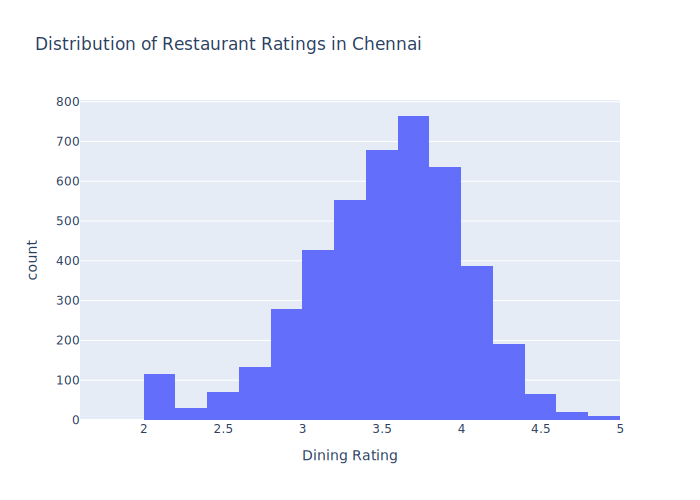

In [33]:
fig = px.histogram(Zomato_Chennai_df, x='Dining Rating', 
                   nbins=20, 
                   title='Distribution of Restaurant Ratings in Chennai',
                  )
fig.show()

### 2. How many restaurants are in Chennai for each type of Cuisine?

In [34]:
Chennai_rest_df = Zomato_Chennai_df.groupby('Cuisine')['Name of Restaurant'].count().reset_index()
Chennai_rest_df.sort_values(by='Name of Restaurant', ascending=False)

,Cuisine,Name of Restaurant
1289,['South Indian'],163
1091,"['Pizza', ' Fast Food']",97
988,"['North Indian', ' Chinese']",89
698,['Fast Food'],83
1219,"['South Indian', ' Chinese']",73
...,...,...
528,"['Chinese', ' South Indian', ' Mughlai', ' Leb...",1
529,"['Chinese', ' South Indian', ' North Indian', ...",1
531,"['Chinese', ' South Indian', ' North Indian', ...",1
532,"['Chinese', ' South Indian', ' North Indian', ...",1


### 3. What are the top 10 highest rated Seafood Restaurant in Chennai?

In [35]:
Seafood_df = raw_df[raw_df['Cuisine'].str.contains('Seafood')]
Seafood_df.sort_values(by='Dining Rating', ascending=False).head(10)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
195,The Marina,Nungambakkam,"['Seafood', ' North Indian', ' Chinese']","['Sea Food', ' Jumbo Prawns', ' Biryani', ' Fi...",800.0,4.8,1082,4.3,373,"['Home Delivery', 'Indoor Seating', 'Table res..."
214,Sera - The Tapas Bar & Restaurant,Gopalapuram,"['Finger Food', ' Seafood', ' Italian', ' Cont...","['Cocktails', ' Pasta', ' Nachos', ' Mashed Po...",800.0,4.5,964,3.4,50,"['Home Delivery', 'Full Bar Available', 'Free ..."
315,Layalee,Ekkaduthangal,"['Arabian', ' BBQ', ' Seafood', ' Chinese', ' ...","['Fish', ' Faluda', ' Shawarma', ' Brownie', '...",350.0,4.4,586,4.1,143,"['Home Delivery', 'Table booking recommended',..."
96,Urban Spatula,Anna Nagar West,"['Continental', ' Seafood', ' Biryani', ' Ital...","['Burgers', ' Pasta', ' Fish', ' Fries', ' Chi...",400.0,4.4,794,4.3,911,"['Home Delivery', 'Free Parking', 'Table booki..."
14,Hotel Paramount,Kilpauk,"['North Indian', ' Chinese', ' Seafood', ' Sou...","['Biryani', ' Butter Chicken', ' Tandoori Chic...",250.0,4.3,1266,4.2,17700,"['Breakfast', 'Home Delivery', 'Indoor Seating..."
133,Azzuri Bay,Adyar,"['Italian', ' Mediterranean', ' Thai', ' Seafo...","['Pasta', ' Pizza', ' Sea Food', ' Tiramisu', ...",500.0,4.3,2430,4.0,369,"['Home Delivery', 'Rooftop', 'Table reservatio..."
9027,Copper Kitchen,Kotturpuram,"['North Indian', ' Chinese', ' Chettinad', ' S...","['Brownie', ' Faluda', ' Biryani', ' Bbq Chick...",500.0,4.3,1739,3.7,8659,"['Home Delivery', 'Indoor Seating', 'Table boo..."
9026,Copper Kitchen,Porur,"['North Indian', ' Chinese', ' Chettinad', ' S...","['Faluda', ' Bbq Chicken', ' Brownie', ' Birya...",500.0,4.3,5073,3.9,26800,"['Home Delivery', 'Sports TV', 'Indoor Seating..."
237,The Cascade,Nungambakkam,"['Seafood', ' Chinese', ' Asian', ' Thai', ' M...","['Momos', ' Phuket Fish', ' Dragon Chicken', '...",500.0,4.3,613,4.1,1886,"['Home Delivery', 'Wheelchair Accessible', 'Va..."
153,The Bayleaf,Gopalapuram,"['Mughlai', ' North Indian', ' Seafood', ' Bir...","['Rolls', ' Fish', ' Kathi Roll', ' Biryani', ...",400.0,4.3,542,4.0,224,"['Home Delivery', 'Indoor Seating', 'Wifi', 'T..."


### 4. Which places have the highest rated restaurant for each cuisine in Chennai ?

In [36]:
# assuming restaurants having rating above 4.5 - are highest rated restaurants

highest_rated_df = Zomato_Chennai_df[Zomato_Chennai_df['Dining Rating'] >=4.5].head(25)
highest_rated_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
24,Eating Circles,Alwarpet,['South Indian'],"['Rose Milk', ' Neer Dosa', ' Thatte Idli', ' ...",125.0,4.7,782,4.2,2744,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
37,Shree Mithai,Chetpet,"['Mithai', ' Street Food', ' Fast Food']","['Chaat', ' Badam Milk', ' Pav Bhaji', ' Panip...",150.0,4.6,1085,4.4,18600,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
50,Andhikkadai,Velachery,['South Indian'],"['Coffee', ' Sweet Kozhukattai', ' Idli', ' Po...",100.0,4.6,908,4.2,17300,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
57,Brownie Heaven,Royapettah,"['Bakery', ' Desserts', ' Beverages']","['Vanilla Ice Cream', ' Brownie Shake', ' Filt...",175.0,4.9,842,4.3,2270,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
59,Mezze,Alwarpet,['Middle Eastern'],"['Baklava', ' Mezze', ' Shawarma', ' Pita Brea...",350.0,4.7,1152,4.2,2249,"['Home Delivery', 'Indoor Seating']"
62,Amadora Gourmet Ice Cream & Sorbet,Nungambakkam,"['Desserts', ' Ice Cream']","['Sandwich', ' Gelato', ' Chocolate Icecreams'...",250.0,4.8,1516,4.5,361,"['Home Delivery', 'Outdoor Seating', 'Desserts..."
67,Pumpkin Tales,Alwarpet,"['Singaporean', ' American', ' European', ' Co...","['Pumpkin Soup', ' Bibimbap', ' Noodle', ' Che...",900.0,4.5,768,4.0,245,"['Breakfast', 'Home Delivery', 'Indoor Seating..."
68,Sandy's Chocolate Laboratory,Nungambakkam,"['Cafe', ' Continental', ' Italian', ' Desserts']","['Tiny Chocolate Cake', ' Hot Chocolate', ' Sa...",700.0,4.5,2252,4.3,1973,"['Breakfast', 'Home Delivery', 'Free Parking',..."
70,Little Italy,Besant Nagar,"['Italian', ' Mexican', ' Salad']","['Pasta', ' Pizza', ' Nachos', ' Tiramisu', ' ...",750.0,4.7,1349,4.2,1435,"['Home Delivery', 'Vegetarian Only', 'Valet Pa..."
75,Fusilli Reasons,Kilpauk,['Fast Food'],"['Nachos', ' Iced Tea', ' Garlic Bread', ' Bro...",200.0,4.7,3042,4.4,3954,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."


### 5. What is the Avg Price Distibution of highest rated restaurant for each Cuisine Type in Chennai ?

In [37]:
highest_rated_price_df = highest_rated_df.groupby(by=['Location', 'Cuisine'])['Price'].mean().reset_index()
highest_rated_price_df.head()

,Location,Cuisine,Price
0,Alwarpet,['Middle Eastern'],350.0
1,Alwarpet,"['Singaporean', ' American', ' European', ' Co...",900.0
2,Alwarpet,['South Indian'],125.0
3,Anna Nagar East,"['Arabian', ' Mughlai', ' North Indian', ' Bir...",500.0
4,Anna Nagar West,"['Rajasthani', ' North Indian']",250.0


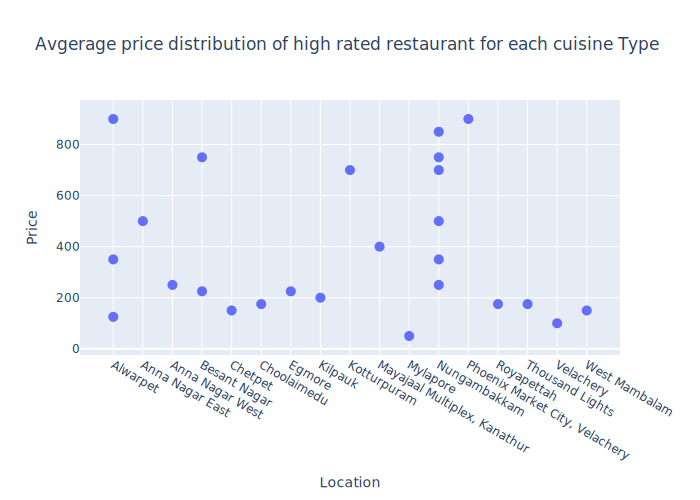

In [38]:
fig = px.scatter(highest_rated_price_df, x="Location", y="Price",
title=' Avgerage price distribution of high rated restaurant for each cuisine Type').update_traces(marker_size=10)
fig.show()

### 6. Which areas have a large number of Chinese Restaurant Market?

In [39]:
chinese_df = Zomato_Chennai_df[Zomato_Chennai_df['Cuisine'].str.contains('Chinese')]
chinese_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",250.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",225.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
5,Dine N Fun,Medavakkam,"['South Indian', ' North Indian', ' Chinese']","['Chicken Grill', ' Shawarma', ' Naan', ' Chic...",225.0,4.1,567,3.8,24700,"['Home Delivery', 'Indoor Seating']"
8,Savoury Sea Shell,Anna Nagar East,"['Arabian', ' Chinese', ' North Indian', ' Leb...","['Shawarma', ' Chicken Grill', ' Brownie', ' S...",700.0,4.2,2564,4.1,21700,"['Home Delivery', 'Indoor Seating', 'Card Upon..."
9,Sangeetha Veg Restaurant,T. Nagar,"['South Indian', ' North Indian', ' Chinese', ...","['Filtered Coffee', ' Chaat', ' Faluda', ' Mas...",400.0,4.4,1578,4.2,39600,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
...,...,...,...,...,...,...,...,...,...,...
11382,Texas Treat,Selaiyur,"['Bakery', ' North Indian', ' Chinese', ' Ital...",Not mentioned,425.0,3.8,9,3.8,43,"['Home Delivery', 'Vegetarian Only', 'Free Par..."
11544,Anandhi Idly Kadai,Medavakkam,"['South Indian', ' Chinese']",Not mentioned,100.0,3.4,24,4.1,778,"['Home Delivery', 'Indoor Seating']"
11545,Anandhi Idly Kadai,Selaiyur,"['South Indian', ' Chinese']",Not mentioned,100.0,3.1,17,4.1,367,"['Breakfast', 'Home Delivery', 'Indoor Seating']"
11736,Adyar Vaishnavas Thattu Idly Kadai,Porur,"['South Indian', ' Sandwich', ' Chinese', ' St...",Not mentioned,100.0,3.2,6,3.9,48,"['Home Delivery', 'Indoor Seating']"


In [40]:
chinese_rest_df = chinese_df.groupby(by='Location').agg({'Name of Restaurant':'count','Price':'mean'}).reset_index().rename(columns={'Name of Restaurant':'Count Of Restaurants'})
chinese_rest_df = chinese_rest_df.sort_values('Count Of Restaurants',ascending=False).head(25)
chinese_rest_df.head()

,Location,Count Of Restaurants,Price
87,Porur,58,245.258621
10,Anna Nagar East,57,319.298246
5,Ambattur,52,207.692308
107,T. Nagar,47,250.531915
123,Velachery,46,288.043478


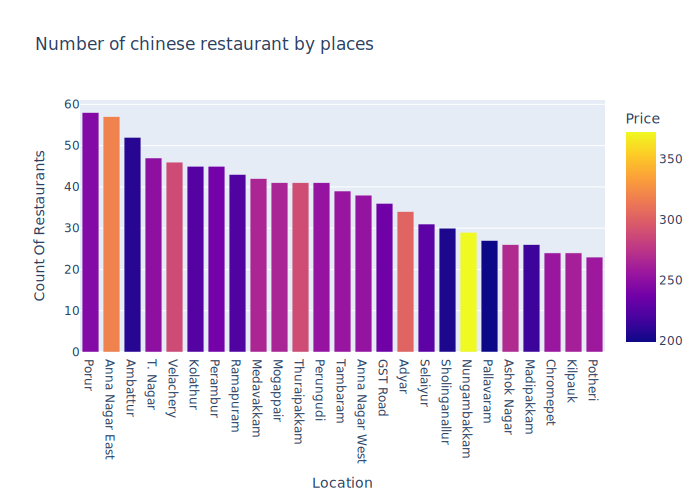

In [41]:
fig=px.bar(chinese_rest_df, x='Location', y='Count Of Restaurants', color='Price',
           title='Number of chinese restaurant by places')
fig.show()

### 7. Is there a relation between Price and Location ?

In [42]:
price_location_df = Zomato_Chennai_df.groupby(['Location'])['Price'].mean().reset_index()
price_location_df 

,Location,Price
0,Abhiramapuram,100.000000
1,Adambakkam,163.815789
2,Adyar,264.432990
3,Akkarai,287.500000
4,Alandur,221.428571
...,...,...
156,Vepery,175.000000
157,Vettuvankeni,237.500000
158,Virugambakkam,212.500000
159,Washermenpet,190.277778


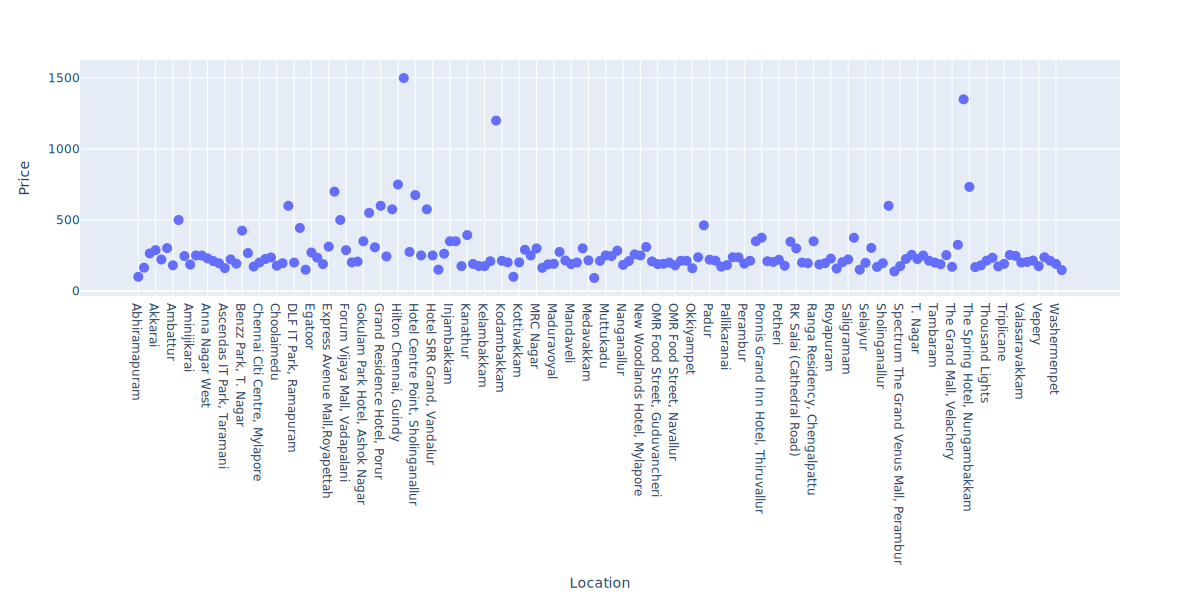

In [43]:
fig = px.scatter(price_location_df, x='Location', y='Price', width=1200, height=600).update_traces(marker_size=10)
fig.show()

### 8. Find the list of affordable restaurants?

In [44]:
Zomato_Chennai_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",250.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",500.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",250.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],250.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",225.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


In [45]:
max_price = Zomato_Chennai_df['Price'].max()
one_fourth_price = max_price/4
one_fourth_price

np.float64(375.0)

In [46]:
# Finding list of restaurants that have price less than and equal to 1/4th of the max price i.e Finding Cheap Restaurant

aff_rest_df = Zomato_Chennai_df[['Name of Restaurant', 'Location', 'Cuisine', 'Top Dishes', 'Price']]
aff_rest_df = aff_rest_df[aff_rest_df['Price'] <= 375]
aff_rest_df.sort_values(by='Price', inplace=True)
aff_rest_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price
108,Rayar's Mess,Mylapore,['South Indian'],"['Pongal', ' Vada', ' Filtered Coffee', ' Idli...",50.0
1518,Lassi Junction,Anna Nagar West,"['Beverages', ' Ice Cream']",Not mentioned,50.0
4564,Iniyavai Delicious Veg Restaurant,Ambattur,['South Indian'],Not mentioned,50.0
5862,A.P.S Chat,Vadapalani,['Street Food'],Not mentioned,50.0
2151,Cane 4 U,Besant Nagar,['Beverages'],"['Sugarcane Juice', ' Fruit Juices']",50.0
...,...,...,...,...,...
8817,Savoury Sea Shell,Thousand Lights,"['Chinese', ' BBQ', ' South Indian']","['Chicken Grill', ' Shawarma', ' Bbq Chicken',...",375.0
10074,Long Live Pizza,Injambakkam,"['Pizza', ' Fast Food']",Not mentioned,375.0
2296,Ponnis Grand Inn,"Ponnis Grand Inn Hotel, Thiruvallur",['Thai'],Not mentioned,375.0
2102,Al Arz Restaurant,George Town,"['Arabian', ' BBQ', ' Chinese', ' North Indian']",Not mentioned,375.0


In [47]:
# Finding the highest rated list of restaurants

highrate_rest_df = Zomato_Chennai_df[['Name of Restaurant', 'Location', 'Cuisine', 'Top Dishes', 'Price', 'Dining Rating']]
highrate_rest_df = highrate_rest_df[highrate_rest_df['Dining Rating'] >= 4.5]
highrate_rest_df.sort_values(by='Price', inplace=True)
highrate_rest_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price,Dining Rating
108,Rayar's Mess,Mylapore,['South Indian'],"['Pongal', ' Vada', ' Filtered Coffee', ' Idli...",50.0,4.7
178,Royal Sandwich Shop,Alwarpet,"['Fast Food', ' Desserts', ' Beverages']","['Brownie', ' Cheese Masala Toast', ' Chocolat...",75.0,4.7
9541,Bombay Kulfi,Anna Nagar East,['Ice Cream'],"['Calcutta Paan', ' Tender Coconut Kulfi', ' P...",100.0,4.6
320,Bombay Kulfi,Adyar,['Ice Cream'],"['Kesar Pista Kulfi', ' Malai Kulfi', ' Chocol...",100.0,4.9
50,Andhikkadai,Velachery,['South Indian'],"['Coffee', ' Sweet Kozhukattai', ' Idli', ' Po...",100.0,4.6
24,Eating Circles,Alwarpet,['South Indian'],"['Rose Milk', ' Neer Dosa', ' Thatte Idli', ' ...",125.0,4.7
37,Shree Mithai,Chetpet,"['Mithai', ' Street Food', ' Fast Food']","['Chaat', ' Badam Milk', ' Pav Bhaji', ' Panip...",150.0,4.6
270,ID,"Sathyam Cinemas Complex, Royapettah",['South Indian'],"['Filtered Coffee', ' Appam', ' Buttermilk', '...",150.0,4.5
155,The Sandwich Shop,West Mambalam,"['Sandwich', ' Fast Food', ' Beverages']","['Mocktails', ' Fries', ' Pizza Sandwich', ' T...",150.0,4.9
209,Cream Stone,Alwarpet,"['Desserts', ' Ice Cream']","['Death By Chocolate', ' Ferrero Rocher', ' Wa...",175.0,4.5


In [48]:
# Now, we'll merge the aff_rest_df with highrate_rest_df to obtain the intersection i.e the list of Affordable Restaurants !!

highrate_aff_df = pd.merge(aff_rest_df, highrate_rest_df, how='inner', on=['Name of Restaurant', 'Location']) 
highrate_aff_df = highrate_aff_df[['Name of Restaurant', 'Price_x', 'Cuisine_x', 'Location', 'Top Dishes_x']]
highrate_aff_df.rename(columns={'NAME':'Name of Restaurant', 'Price_x':'Price', 'Location':'Location', 
                                'Top Dishes_x':'Top Dishes'}, inplace=True)

In [49]:
# Affordable Restaurants with low price and high rating  

highrate_aff_df

,Name of Restaurant,Price,Cuisine_x,Location,Top Dishes
0,Rayar's Mess,50.0,['South Indian'],Mylapore,"['Pongal', ' Vada', ' Filtered Coffee', ' Idli..."
1,Royal Sandwich Shop,75.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Not mentioned
2,Royal Sandwich Shop,75.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Not mentioned
3,Royal Sandwich Shop,75.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,"['Brownie', ' Cheese Masala Toast', ' Chocolat..."
4,Bombay Kulfi,100.0,['Ice Cream'],Anna Nagar East,"['Calcutta Paan', ' Tender Coconut Kulfi', ' P..."
5,Bombay Kulfi,100.0,['Ice Cream'],Adyar,"['Kesar Pista Kulfi', ' Malai Kulfi', ' Chocol..."
6,Andhikkadai,100.0,['South Indian'],Velachery,"['Coffee', ' Sweet Kozhukattai', ' Idli', ' Po..."
7,Eating Circles,125.0,['South Indian'],Alwarpet,"['Rose Milk', ' Neer Dosa', ' Thatte Idli', ' ..."
8,Shree Mithai,150.0,"['Mithai', ' Street Food', ' Fast Food']",Chetpet,"['Chaat', ' Badam Milk', ' Pav Bhaji', ' Panip..."
9,The Sandwich Shop,150.0,"['Sandwich', ' Fast Food', ' Beverages']",West Mambalam,"['Mocktails', ' Fries', ' Pizza Sandwich', ' T..."
